Using device: cuda


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\jack/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100.0%



Epoch [1/50]
----------------------------------------
Train Loss: 1.6355 | Train Acc: 73.60%
Val   Loss: 0.5254 | Val Acc: 92.70%

Epoch [2/50]
----------------------------------------
Train Loss: 0.4260 | Train Acc: 92.65%
Val   Loss: 0.2454 | Val Acc: 95.31%

Epoch [3/50]
----------------------------------------
Train Loss: 0.2441 | Train Acc: 95.17%
Val   Loss: 0.1860 | Val Acc: 95.82%

Epoch [4/50]
----------------------------------------
Train Loss: 0.1789 | Train Acc: 96.08%
Val   Loss: 0.1572 | Val Acc: 96.57%

Epoch [5/50]
----------------------------------------
Train Loss: 0.1461 | Train Acc: 96.55%
Val   Loss: 0.1460 | Val Acc: 96.79%

Epoch [6/50]
----------------------------------------
Train Loss: 0.1238 | Train Acc: 96.95%
Val   Loss: 0.1433 | Val Acc: 96.77%

Epoch [7/50]
----------------------------------------
Train Loss: 0.1119 | Train Acc: 97.20%
Val   Loss: 0.1378 | Val Acc: 96.95%

Epoch [8/50]
----------------------------------------
Train Loss: 0.1001 | Train A

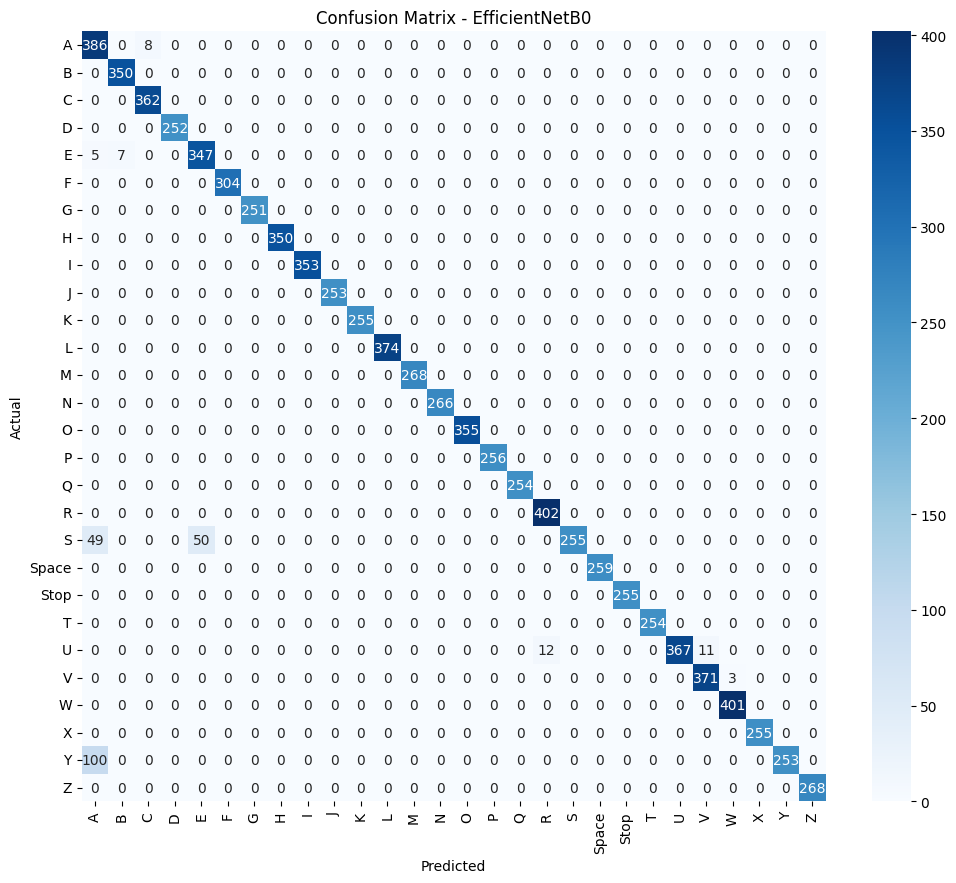

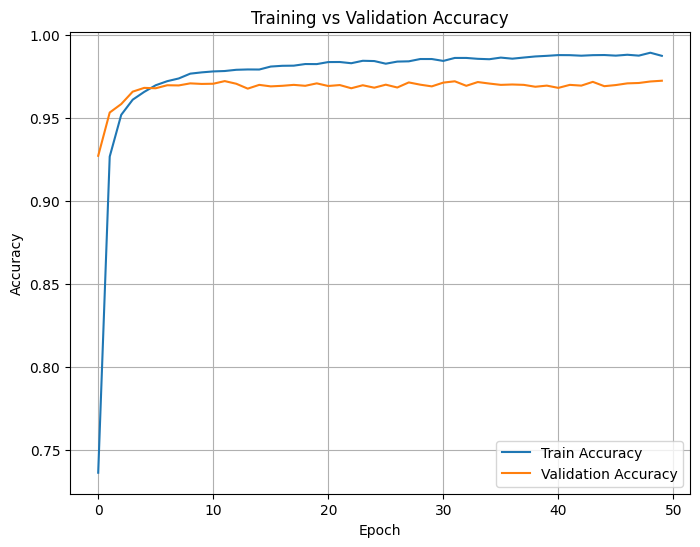

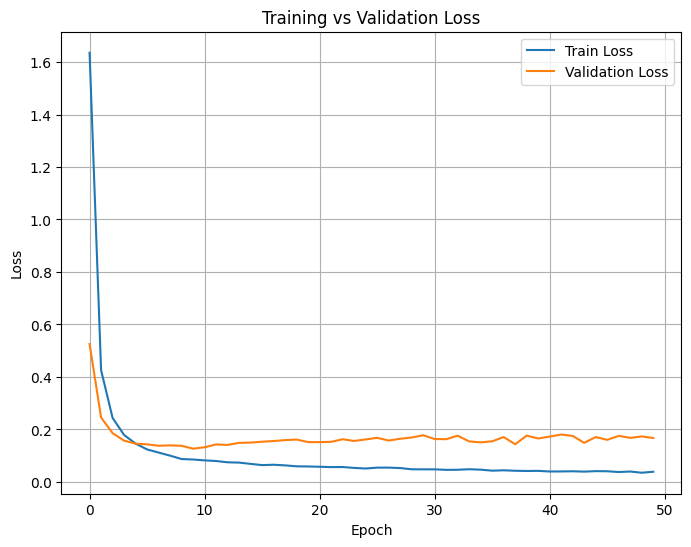


All results saved to: D:/Projects/Capstone Project/Vision based hand sign detection & classification usig DL models/runs/efficientnet_b0
Total Training Time: 185.75 minutes


In [ ]:
import os
import time
import copy
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch import nn, optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# ================= CONFIG =================
DATASET_PATH = r"specify you're own dataset's" #vishnu

RUNS_DIR = r"specify you're output directory/runs/efficientnet_b0"
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_EPOCHS = 50
BATCH_SIZE = 32
LR = 0.0001
IMG_SIZE = 224

os.makedirs(RUNS_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

plt.ion()  # interactive mode ON

# ================= TRANSFORMS =================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ================= DATA =================

train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=val_transform
)

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=4)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         num_workers=4)

class_names = train_dataset.classes
num_classes = len(class_names)

with open(os.path.join(RUNS_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f)

# ================= MODEL =================

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=LR)

# ================= TRAINING =================

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 40)

    # TRAIN
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc.item())

    # VALIDATION
    model.eval()
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels)

    val_epoch_loss = val_loss / len(test_dataset)
    val_epoch_acc = val_corrects.double() / len(test_dataset)

    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc.item())

    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"Val   Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc*100:.2f}%")

    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())

# ================= SAVE BEST MODEL =================

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(),
           os.path.join(RUNS_DIR, "best_efficientnet_b0.pth"))

print("\nBest Validation Accuracy:", best_acc.item())

# ================= METRICS =================

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(all_labels, all_preds,
                            target_names=class_names))

# ================= CONFUSION MATRIX =================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - EfficientNetB0")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(os.path.join(RUNS_DIR, "confusion_matrix.png"))
plt.show()

# ================= ACCURACY GRAPH =================

plt.figure(figsize=(8,6))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(RUNS_DIR, "accuracy_plot.png"))
plt.show()

# ================= LOSS GRAPH =================

plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(RUNS_DIR, "loss_plot.png"))
plt.show()

print("\nAll results saved to:", RUNS_DIR)
print("Total Training Time: {:.2f} minutes".format((time.time() - start_time)/60))